In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
from src.pipeline import run_pipeline
from src.embedding import predict_mask
from src.metrics import show_clusters, show_mismatches

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

terms = ["fam"]

all_results = []

for term in terms:
    df = pd.read_csv(f"data/{term}_annotation.csv")

    res_kmeans = run_pipeline(df, tokenizer, model, device, method="kmeans")
    res_agglo = run_pipeline(df, tokenizer, model, device, method="agglo")

    res_kmeans_k3 = run_pipeline(df, tokenizer, model, device,
                            method="kmeans", k_mode="forced", forced_k=3)

    res_agglo_k3 = run_pipeline(df, tokenizer, model, device,
                           method="agglo", k_mode="forced", forced_k=3)

    print(res_kmeans)
    print(res_agglo)
    print(res_kmeans_k3)
    print(res_agglo_k3)

c:\Users\Таня\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


{'metrics': {'term': 'fam', 'setting': 'auto_k', 'k': 2, 'silhouette': 0.17688100039958954, 'pairwise_precision': 0.371976647206005, 'pairwise_recall': 0.6545988258317026, 'pairwise_f1': 0.4743839744726112, 'ARI': 0.01123011543461327, 'NMI': 0.004080335433810836, 'purity': 0.49056603773584906}, 'labels_pred': array([1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0]), 'X': array([[-0.20453191,  0.2443261 ,  0.48996517, ..., -0.1913154 ,
         0.09593015, -0.00565054],
       [-0.48745728,  0.47606504,  0.49667764, ..., -0.1707851 ,
        -0.11368762, -0.56274754],
       [ 0.06643269,  0.16997185,  0.6250687 , ...,  0.341851  ,
         0.11883096, -0.03556769],
       ...,
       [ 0.127757

In [ ]:
example_text = "my [MASK] is coming tonight"

words = predict_mask(tokenizer, model, example_text, device)

print("Predicted words:", words)

In [ ]:
res = run_pipeline(df, tokenizer, model, device, method="kmeans")

print(res["metrics"])

show_clusters(
    res["texts"],
    res["labels"],
    res["gold"]
)

In [7]:
from collections import Counter

def cluster_synonyms_freq(texts, term, tokenizer, mlm_model, device, top_k=5):
    all_preds = []

    for text in texts:
        if term not in text:
            continue

        masked = text.replace(term, "[MASK]")
        preds = predict_mask(tokenizer, mlm_model, masked, device)

        all_preds.extend(preds)
    all_preds = [p for p in all_preds if p not in STOPWORDS]
    counter = Counter(all_preds)

    return counter.most_common(top_k)

import torch
import torch.nn.functional as F

def cluster_synonyms_logits(texts, term, tokenizer, mlm_model, device, top_k=5):

    mlm_model.eval()
    sum_logits = None
    count = 0

    for text in texts:
        if term not in text:
            continue

        masked = text.replace(term, "[MASK]")
        inputs = tokenizer(masked, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = mlm_model(**inputs)

        mask_positions = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)

        if len(mask_positions[0]) == 0:
            continue

        mask_idx = mask_positions[1][0]

        logits = outputs.logits[0, mask_idx, :]  # [vocab]

        if sum_logits is None:
            sum_logits = logits
        else:
            sum_logits += logits

        count += 1

    if count == 0:
        return []

    avg_logits = sum_logits / count
    probs = F.softmax(avg_logits, dim=-1)

    top_ids = torch.topk(probs, top_k).indices.tolist()
    
    tokens = [tokenizer.decode([i]).strip() for i in top_ids]
    tokens = [t for t in tokens if t not in STOPWORDS]
    return tokens

c:\Users\Таня\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model)


TERM: fam

--- random | mask | fixed ---


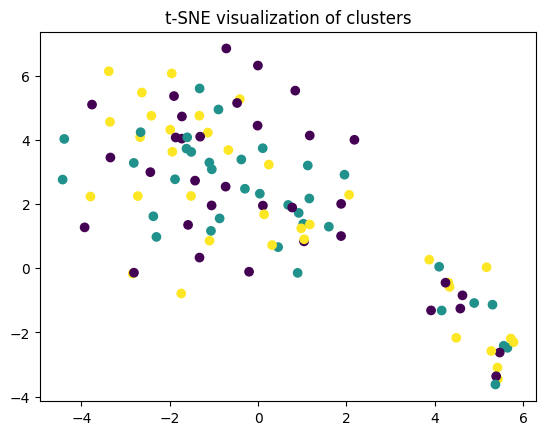


=== MISCLASSIFIED EXAMPLES ===

TEXT: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
GOLD: social PRED: 2

TEXT: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
GOLD: bio PRED: 0

TEXT: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
GOLD: bio PRED: 2

TEXT: dim sum with the [MASK]
GOLD: bio PRED: 2

TEXT: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
GOLD: bio PRED: 0

TEXT: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space wi

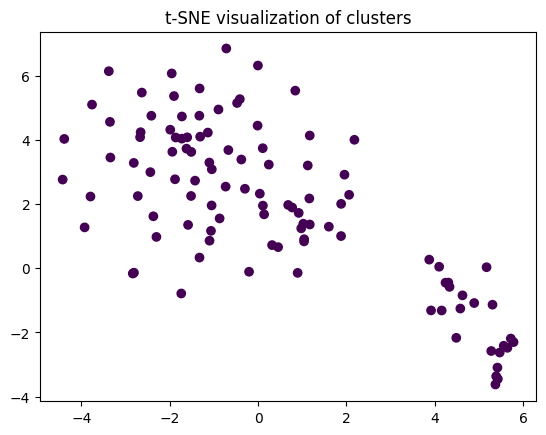


=== MISCLASSIFIED EXAMPLES ===

TEXT: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
GOLD: social PRED: 0

TEXT: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
GOLD: bio PRED: 0

TEXT: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
GOLD: bio PRED: 0

TEXT: dim sum with the [MASK]
GOLD: bio PRED: 0

TEXT: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
GOLD: bio PRED: 0

TEXT: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space wi

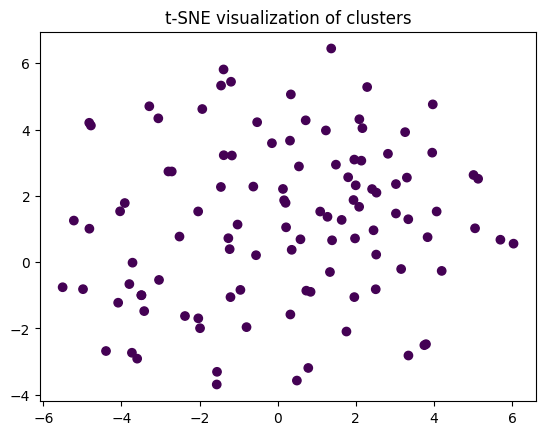


=== MISCLASSIFIED EXAMPLES ===

TEXT: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
GOLD: social PRED: 0

TEXT: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
GOLD: bio PRED: 0

TEXT: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
GOLD: bio PRED: 0

TEXT: dim sum with the [MASK]
GOLD: bio PRED: 0

TEXT: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
GOLD: bio PRED: 0

TEXT: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space wi

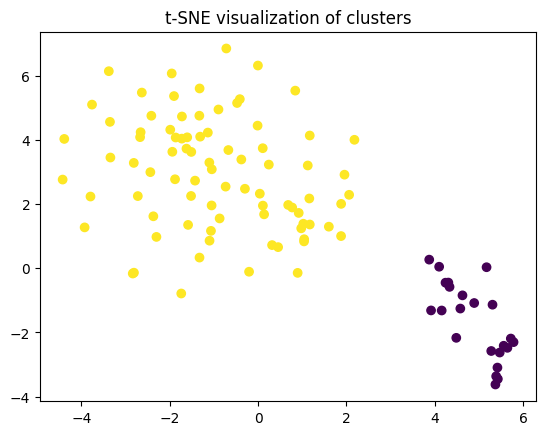


=== MISCLASSIFIED EXAMPLES ===

TEXT: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
GOLD: social PRED: 1

TEXT: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
GOLD: bio PRED: 1

TEXT: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
GOLD: bio PRED: 1

TEXT: dim sum with the [MASK]
GOLD: bio PRED: 0

TEXT: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
GOLD: bio PRED: 0

TEXT: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space wi

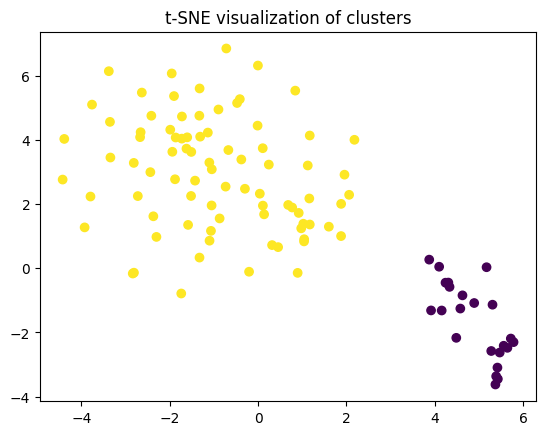


=== MISCLASSIFIED EXAMPLES ===

TEXT: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
GOLD: social PRED: 1

TEXT: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
GOLD: bio PRED: 1

TEXT: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
GOLD: bio PRED: 1

TEXT: dim sum with the [MASK]
GOLD: bio PRED: 0

TEXT: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
GOLD: bio PRED: 0

TEXT: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space wi

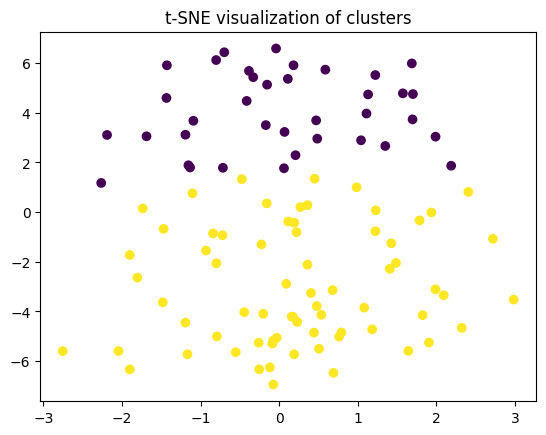


=== MISCLASSIFIED EXAMPLES ===

TEXT: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
GOLD: social PRED: 1

TEXT: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
GOLD: bio PRED: 1

TEXT: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
GOLD: bio PRED: 1

TEXT: dim sum with the [MASK]
GOLD: bio PRED: 1

TEXT: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
GOLD: bio PRED: 1

TEXT: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space wi

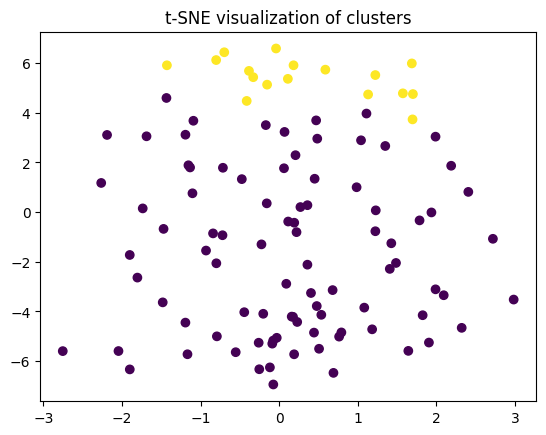


=== MISCLASSIFIED EXAMPLES ===

TEXT: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
GOLD: social PRED: 0

TEXT: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
GOLD: bio PRED: 0

TEXT: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
GOLD: bio PRED: 0

TEXT: dim sum with the [MASK]
GOLD: bio PRED: 0

TEXT: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
GOLD: bio PRED: 0

TEXT: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space wi

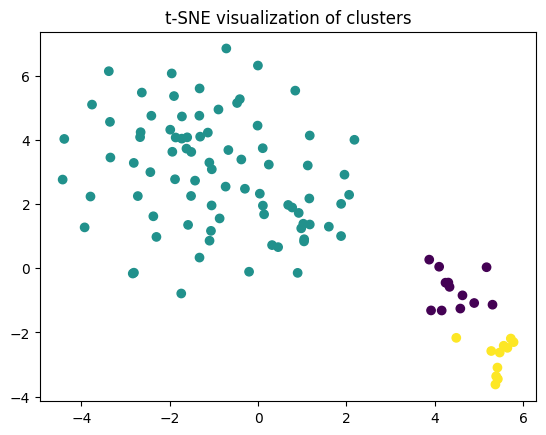


=== MISCLASSIFIED EXAMPLES ===

TEXT: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
GOLD: social PRED: 1

TEXT: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
GOLD: bio PRED: 1

TEXT: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
GOLD: bio PRED: 1

TEXT: dim sum with the [MASK]
GOLD: bio PRED: 0

TEXT: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
GOLD: bio PRED: 0

TEXT: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space wi

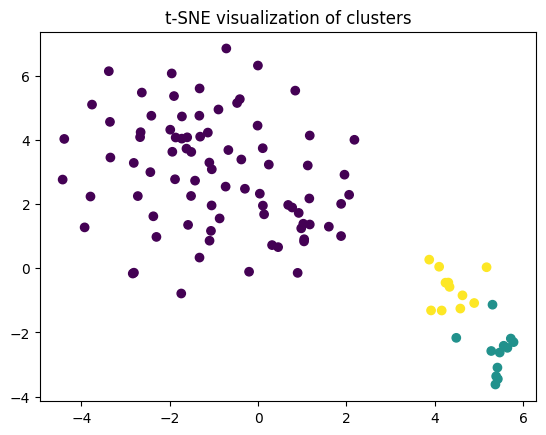


=== MISCLASSIFIED EXAMPLES ===

TEXT: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
GOLD: social PRED: 0

TEXT: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
GOLD: bio PRED: 0

TEXT: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
GOLD: bio PRED: 0

TEXT: dim sum with the [MASK]
GOLD: bio PRED: 2

TEXT: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
GOLD: bio PRED: 2

TEXT: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space wi

In [8]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
from transformers import AutoModelForMaskedLM

from src.pipeline import run_pipeline
from src.embedding import predict_mask
from src.metrics import show_clusters, show_mismatches
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_tsne(X, labels):

    tsne = TSNE(n_components=2, random_state=42)
    X_2d = tsne.fit_transform(X)

    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels)
    plt.title("t-SNE visualization of clusters")
    plt.show()
# -------------------------
# DEVICE
# -------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")


encoder_model = AutoModel.from_pretrained("bert-base-uncased")
mlm_model = AutoModelForMaskedLM.from_pretrained("bert-base-uncased")

STOPWORDS = set([
    ",", ".", "!", "-", "'", "and", "the", "a", "of", "to"
])
# -------------------------
# TERMS
# -------------------------
terms = ["fam"]

all_results = []

# -------------------------
# EXPERIMENT LOOP
# -------------------------
for term in terms:

    print("\n========================")
    print("TERM:", term)
    print("========================")

    df = pd.read_csv(f"data/{term}_annotation.csv")

    configs = [
    # RANDOM BASELINE
    ("random", "mask", "fixed", 3),

    # SIMPLE BASELINE (1 cluster)
    ("baseline", "mask", "fixed", 1),

    # TF-IDF baseline (НОВЫЙ)
    ("kmeans", "tfidf", "auto", None),

    # MAIN MODELS
    ("kmeans", "mask", "auto", None),
    ("agglo", "mask", "auto", None),

    ("kmeans", "cls", "auto", None),
    ("agglo", "cls", "auto", None),

    # FIXED K
    ("kmeans", "mask", "forced", 3),
    ("agglo", "mask", "forced", 3),
]

    for method, emb, k_mode, k in configs:

        print(f"\n--- {method} | {emb} | {k_mode} ---")

        res = run_pipeline(
            df,
            tokenizer,
            encoder_model,
            device,
            method=method,
            embedding_type=emb,
            k_mode=k_mode,
            forced_k=k
        )

        plot_tsne(res["X"], res["labels"])

        show_mismatches(
            res["texts"],
            res["gold"],
            res["labels"]
        )
        # -------------------------
        # METRICS
        # -------------------------
        print(res["metrics"])

        row = res["metrics"].copy()
        row["method"] = method
        row["embedding"] = emb
        all_results.append(row)

        # -------------------------
        # QUALITATIVE ANALYSIS
        # -------------------------
        if method in ["kmeans", "agglo", "hybrid"]:
            show_clusters(
                res["texts"],
                res["labels"],
                res["gold"]
            )

    # -------------------------
    # CLUSTER-LEVEL SYNONYMS
    # -------------------------
    print("\n=== CLUSTER-LEVEL SYNONYMS ===")

    clusters = {}
    for text, label in zip(res["texts"], res["labels"]):
        clusters.setdefault(label, []).append(text)

    for cluster_id, texts_cluster in clusters.items():

        print(f"\n--- Cluster {cluster_id} ---")

        # Method 1: frequency
        freq_syns = cluster_synonyms_freq(
            texts_cluster,
            term,
            tokenizer,
            mlm_model,
            device
        )

        print("Freq:", freq_syns)

    # Method 2: logits
        logit_syns = cluster_synonyms_logits(
            texts_cluster,
            term,
            tokenizer,
            mlm_model,
            device
        )

        print("Logits:", logit_syns)


# -------------------------
# SAVE RESULTS
# -------------------------
df_results = pd.DataFrame(all_results)
df_results.to_csv("results/results.csv", index=False)

print("\nFINAL RESULTS:")
print(df_results)

In [4]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
from transformers import AutoModelForMaskedLM

from src.pipeline import run_pipeline
from src.embedding import predict_mask
from src.metrics import show_clusters, show_mismatches
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_tsne(X, labels):

    tsne = TSNE(n_components=2, random_state=42)
    X_2d = tsne.fit_transform(X)

    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels)
    plt.title("t-SNE visualization of clusters")
    plt.show()
# -------------------------
# DEVICE
# -------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")


encoder_model = AutoModel.from_pretrained("bert-base-uncased")
mlm_model = AutoModelForMaskedLM.from_pretrained("bert-base-uncased")

# -------------------------
# TERMS
# -------------------------
terms = ["manifest"]

all_results = []

# -------------------------
# EXPERIMENT LOOP
# -------------------------
for term in terms:

    print("\n========================")
    print("TERM:", term)
    print("========================")

    df = pd.read_csv(f"data/{term}_annotation.csv")

    configs = [
    # RANDOM BASELINE
    ("random", "mask", "fixed", 3),

    # SIMPLE BASELINE (1 cluster)
    ("baseline", "mask", "fixed", 1),

    # TF-IDF baseline (НОВЫЙ)
    ("kmeans", "tfidf", "auto", None),

    # MAIN MODELS
    ("kmeans", "mask", "auto", None),
    ("agglo", "mask", "auto", None),

    ("kmeans", "cls", "auto", None),
    ("agglo", "cls", "auto", None),

    # FIXED K
    ("kmeans", "mask", "forced", 3),
    ("agglo", "mask", "forced", 3),
]

    for method, emb, k_mode, k in configs:

        print(f"\n--- {method} | {emb} | {k_mode} ---")

        res = run_pipeline(
            df,
            tokenizer,
            encoder_model,
            device,
            method=method,
            embedding_type=emb,
            k_mode=k_mode,
            forced_k=k
        )

        plot_tsne(res["X"], res["labels"])

        show_mismatches(
            res["texts"],
            res["gold"],
            res["labels"]
        )
        # -------------------------
        # METRICS
        # -------------------------
        print(res["metrics"])

        row = res["metrics"].copy()
        row["method"] = method
        row["embedding"] = emb
        all_results.append(row)

        # -------------------------
        # QUALITATIVE ANALYSIS
        # -------------------------
        if method in ["kmeans", "agglo", "hybrid"]:
            show_clusters(
                res["texts"],
                res["labels"],
                res["gold"]
            )

    # -------------------------
    # SYNONYM DEMO
    # -------------------------
    print("\n================ SYNONYM DEMO ================")

    example = df["context"].iloc[0]
    term_word = df["word"].iloc[0]

    masked = example.replace(term_word, "[MASK]")

    print("Original:", example)
    print("Masked:", masked)

    print("Predicted tokens:")
    print(predict_mask(tokenizer, mlm_model, masked, device))


# -------------------------
# SAVE RESULTS
# -------------------------
df_results = pd.DataFrame(all_results)
df_results.to_csv("results/results.csv", index=False)

print("\nFINAL RESULTS:")
print(df_results)

c:\Users\Таня\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model)


TERM: manifest

--- random | mask | fixed ---


ValueError: Input contains NaN.